In [19]:
# ============================================================
# BÉNIN SENTINEL 360 — NOTEBOOK DATA ANALYST
# Visualisations par axe
# ============================================================

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium.plugins import HeatMap, TimestampedGeoJson
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Style global
# ------------------------------------------------------------

px.defaults.template = "plotly_white"

COLORS = {
    "blue": "#1F77B4",
    "orange": "#FF7F0E",
    "red": "#D62728",
    "green": "#2CA02C",
    "yellow": "#F2C94C",
    "purple": "#7B2CBF",
    "gray": "#6C757D",
    "dark": "#0B1F3A"
}

# ------------------------------------------------------------
# Chargement des données
# ------------------------------------------------------------

DATA_PATH = "../data/processed/benin_events_gold.parquet"

df = pd.read_parquet(DATA_PATH)

# Sécurisation des dates
df["date"] = pd.to_datetime(df["SQLDATE"].astype(str), errors="coerce")
df = df.dropna(subset=["date"])

df["month"] = df["date"].dt.to_period("M").astype(str)
df["week"] = df["date"].dt.to_period("W").astype(str)

# Sécurisation colonnes numériques
numeric_cols = [
    "NumArticles", "NumMentions", "NumSources",
    "GoldsteinScale", "AvgTone",
    "ActionGeo_Lat", "ActionGeo_Long"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Shape :", df.shape)
print("Période :", df["date"].min().date(), "→", df["date"].max().date())
df.head()

Shape : (21574, 43)
Période : 2025-01-01 → 2025-12-30


,GLOBALEVENTID,DATEADDED,SQLDATE,YEAR,MonthYear,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,...,sentiment_score,event_date,period,week_label,source_domain,media_lang_group,has_geo,date,month,week
0,1248528475,2025-06-08 19:00:00,2025-05-09,2025,202505,1,192,192,19,4,...,0.103896,2025-06-08 19:00:00,2025-06,2025-06-02/2025-06-08,dailypost.ng,autre,True,2025-05-09,2025-05,2025-05-05/2025-05-11
1,1248528476,2025-06-08 19:00:00,2025-05-09,2025,202505,1,192,192,19,4,...,0.103896,2025-06-08 19:00:00,2025-06,2025-06-02/2025-06-08,dailypost.ng,autre,True,2025-05-09,2025-05,2025-05-05/2025-05-11
2,1279391064,2025-12-15 16:00:00,2025-12-14,2025,202512,1,080,080,08,2,...,-0.280702,2025-12-15 16:00:00,2025-12,2025-12-15/2025-12-21,allafrica.com,anglophone,True,2025-12-14,2025-12,2025-12-08/2025-12-14
3,1277024180,2025-12-01 15:30:00,2025-11-24,2025,202511,0,040,040,04,1,...,-0.474138,2025-12-01 15:30:00,2025-12,2025-12-01/2025-12-07,dailytrust.com,anglophone,True,2025-11-24,2025-11,2025-11-24/2025-11-30
4,1277024181,2025-12-01 15:30:00,2025-11-24,2025,202511,0,040,040,04,1,...,-0.474138,2025-12-01 15:30:00,2025-12,2025-12-01/2025-12-07,dailytrust.com,anglophone,True,2025-11-24,2025-11,2025-11-24/2025-11-30


In [14]:
pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 8.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inference 0.54.2 requires numpy<2.3.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.31.1 which is incompatible.
label-studio 1.20.0 requires cryptography>=44.0.1, but you have cryptography 43.0.3 which is incompatible.
label-studio 1.20.0 requires redis<5.3.0,>=5.2.1, but you have redis 5.0.8 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


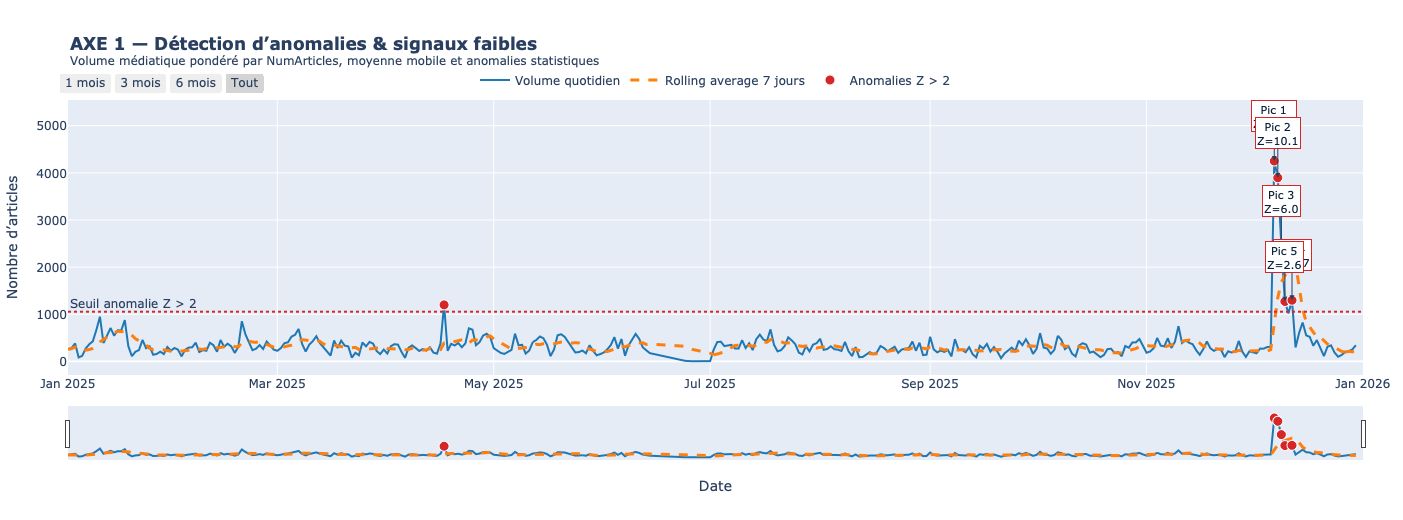

Insight Axe 1 :
Les pics rouges correspondent aux jours où le volume médiatique dépasse significativement son niveau normal. La rolling average permet de détecter une montée progressive avant certains pics, ce qui correspond à des signaux faibles utiles pour l’anticipation.


In [23]:
# ============================================================
# AXE 1 — Détection d'anomalies & signaux faibles
# ============================================================

daily = (
    df.groupby("date")
    .agg(
        volume_articles=("NumArticles", "sum"),
        nb_events=("date", "size"),
        avg_tone=("AvgTone", "mean"),
        avg_goldstein=("GoldsteinScale", "mean")
    )
    .reset_index()
)

# Moyenne mobile 7 jours
daily["rolling_7j"] = daily["volume_articles"].rolling(window=7, min_periods=1).mean()

# Z-score
daily_mean = daily["volume_articles"].mean()
daily_std = daily["volume_articles"].std()

daily["z_score"] = (daily["volume_articles"] - daily_mean) / daily_std

# Seuil statistique
z_threshold = 2
volume_threshold = daily_mean + z_threshold * daily_std

anomalies = daily[daily["z_score"] > z_threshold].copy()

# On limite les annotations aux plus gros pics pour éviter surcharge
top_anomalies = anomalies.sort_values("volume_articles", ascending=False).head(5)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily["date"],
    y=daily["volume_articles"],
    mode="lines",
    name="Volume quotidien",
    line=dict(color=COLORS["blue"], width=2),
    hovertemplate="<b>Date</b>: %{x}<br><b>Articles</b>: %{y}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=daily["date"],
    y=daily["rolling_7j"],
    mode="lines",
    name="Rolling average 7 jours",
    line=dict(color=COLORS["orange"], width=3, dash="dash"),
    hovertemplate="<b>Date</b>: %{x}<br><b>Moyenne mobile</b>: %{y:.0f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=anomalies["date"],
    y=anomalies["volume_articles"],
    mode="markers",
    name="Anomalies Z > 2",
    marker=dict(color=COLORS["red"], size=10, line=dict(color="white", width=1)),
    customdata=np.round(anomalies["z_score"], 2),
    hovertemplate="<b>Anomalie</b><br>Date: %{x}<br>Articles: %{y}<br>Z-score: %{customdata}<extra></extra>"
))

fig.add_hline(
    y=volume_threshold,
    line_dash="dot",
    line_color=COLORS["red"],
    annotation_text="Seuil anomalie Z > 2",
    annotation_position="top left"
)

for i, row in enumerate(top_anomalies.itertuples(), start=1):
    fig.add_annotation(
        x=row.date,
        y=row.volume_articles,
        text=f"Pic {i}<br>Z={row.z_score:.1f}",
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-45,
        bgcolor="white",
        bordercolor=COLORS["red"],
        borderwidth=1,
        font=dict(size=11, color=COLORS["dark"])
    )

fig.update_layout(
    title="<b>AXE 1 — Détection d’anomalies & signaux faibles</b><br><sup>Volume médiatique pondéré par NumArticles, moyenne mobile et anomalies statistiques</sup>",
    xaxis_title="Date",
    yaxis_title="Nombre d’articles",
    hovermode="x unified",
    width=1200,
    height=520,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=60, r=40, t=100, b=60),
    xaxis=dict(
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1 mois", step="month", stepmode="backward"),
                dict(count=3, label="3 mois", step="month", stepmode="backward"),
                dict(count=6, label="6 mois", step="month", stepmode="backward"),
                dict(step="all", label="Tout")
            ])
        )
    )
)

fig.show()

print("Insight Axe 1 :")
print(
    "Les pics rouges correspondent aux jours où le volume médiatique dépasse significativement "
    "son niveau normal. La rolling average permet de détecter une montée progressive avant certains pics, "
    "ce qui correspond à des signaux faibles utiles pour l’anticipation."
)

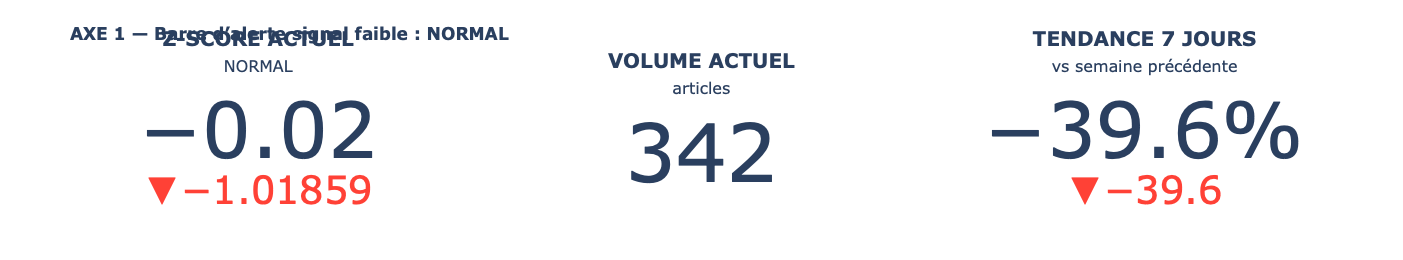

In [25]:
# ============================================================
# AXE 1 — Barre d'alerte signal faible
# ============================================================

latest = daily.sort_values("date").iloc[-1]

latest_z = latest["z_score"]
latest_volume = latest["volume_articles"]
latest_rolling = latest["rolling_7j"]

previous_7d = daily.sort_values("date").tail(14).head(7)["volume_articles"].mean()
last_7d = daily.sort_values("date").tail(7)["volume_articles"].mean()

trend_pct = ((last_7d - previous_7d) / previous_7d) * 100 if previous_7d != 0 else 0

if latest_z >= 2:
    alert_status = "ALERTE"
    alert_color = COLORS["red"]
elif latest_z >= 1:
    alert_status = "SURVEILLANCE"
    alert_color = COLORS["orange"]
else:
    alert_status = "NORMAL"
    alert_color = COLORS["green"]

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number+delta",
    value=latest_z,
    number={"valueformat": ".2f"},
    delta={"reference": 1, "relative": False},
    title={"text": f"<b>Z-SCORE ACTUEL</b><br><span style='font-size:0.8em'>{alert_status}</span>"},
    domain={"x": [0, 0.33], "y": [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=latest_volume,
    number={"valueformat": ",.0f"},
    title={"text": "<b>VOLUME ACTUEL</b><br><span style='font-size:0.8em'>articles</span>"},
    domain={"x": [0.34, 0.66], "y": [0, 1]}
))

fig.add_trace(go.Indicator(
    mode="number+delta",
    value=trend_pct,
    number={"suffix": "%", "valueformat": ".1f"},
    delta={"reference": 0},
    title={"text": "<b>TENDANCE 7 JOURS</b><br><span style='font-size:0.8em'>vs semaine précédente</span>"},
    domain={"x": [0.67, 1], "y": [0, 1]}
))

fig.update_layout(
    title=f"<b>AXE 1 — Barre d’alerte signal faible : {alert_status}</b>",
    width=1100,
    height=260,
    paper_bgcolor="white",
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.show()

In [27]:
# ============================================================
# AXE 2 — Score composite Sentinel
# ============================================================

# Score brut : combinaison "nature de l'événement" × "ton médiatique"
df["sentinel_raw"] = df["GoldsteinScale"] * df["AvgTone"]

# Interprétation :
# Plus le score brut est bas, plus la situation est tendue.
# On inverse pour créer un score de stabilité positif.
raw_min = df["sentinel_raw"].min()
raw_max = df["sentinel_raw"].max()

df["sentinel_score"] = 100 * (df["sentinel_raw"] - raw_min) / (raw_max - raw_min)

# Score global actuel = moyenne des 30 derniers jours
latest_date = df["date"].max()
last_30_days = df[df["date"] >= latest_date - pd.Timedelta(days=30)]

current_score = last_30_days["sentinel_score"].mean()

def stability_label(score):
    if score < 20:
        return "Critique"
    elif score < 40:
        return "Instable"
    elif score < 60:
        return "Fragile"
    elif score < 80:
        return "Stable"
    else:
        return "Très stable"

current_label = stability_label(current_score)

current_score, current_label

(46.921910883390254, 'Fragile')

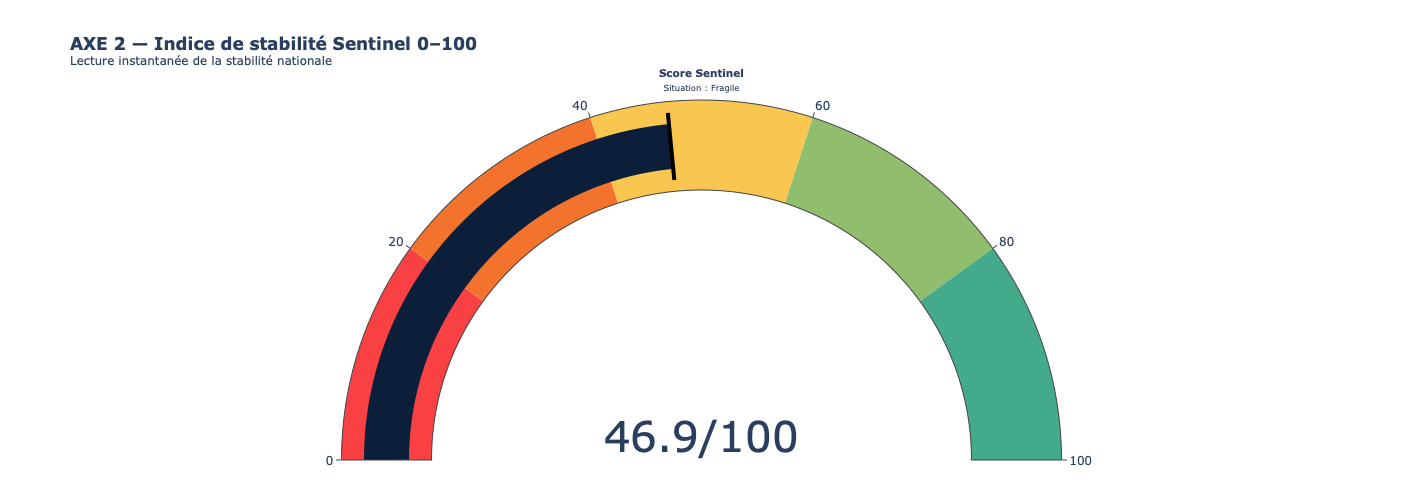

Insight Axe 2 : Le score Sentinel actuel est de 46.9/100, classé 'Fragile'.


In [29]:
# ============================================================
# AXE 2 — Gauge chart Score Sentinel
# ============================================================

fig = go.Figure(go.Indicator(
    mode="gauge+number",
    value=current_score,
    number={"suffix": "/100", "font": {"size": 42}},
    title={
        "text": f"<b>Score Sentinel</b><br><span style='font-size:0.8em'>Situation : {current_label}</span>"
    },
    gauge={
        "axis": {"range": [0, 100], "tickwidth": 1},
        "bar": {"color": COLORS["dark"]},
        "steps": [
            {"range": [0, 20], "color": "#F94144"},
            {"range": [20, 40], "color": "#F3722C"},
            {"range": [40, 60], "color": "#F9C74F"},
            {"range": [60, 80], "color": "#90BE6D"},
            {"range": [80, 100], "color": "#43AA8B"},
        ],
        "threshold": {
            "line": {"color": "black", "width": 4},
            "thickness": 0.75,
            "value": current_score
        }
    }
))

fig.update_layout(
    title="<b>AXE 2 — Indice de stabilité Sentinel 0–100</b><br><sup>Lecture instantanée de la stabilité nationale</sup>",
    width=850,
    height=500,
    margin=dict(l=40, r=40, t=100, b=40)
)

fig.show()

print(f"Insight Axe 2 : Le score Sentinel actuel est de {current_score:.1f}/100, classé '{current_label}'.")

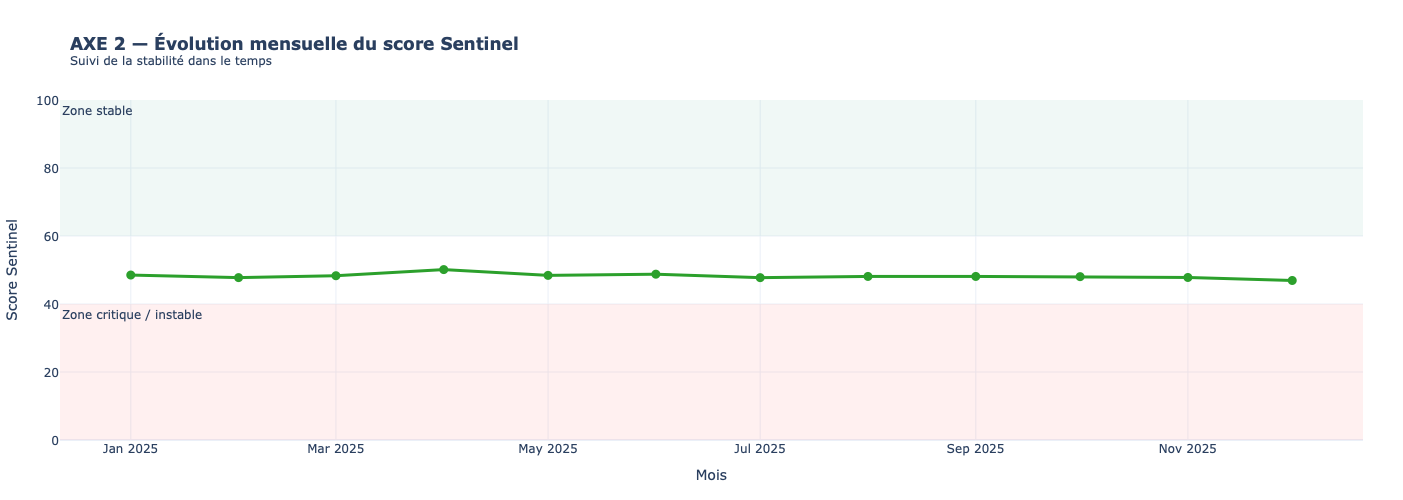

In [31]:
# ============================================================
# AXE 2 — Évolution mensuelle du score Sentinel
# ============================================================

monthly_score = (
    df.groupby("month")
    .agg(
        sentinel_score=("sentinel_score", "mean"),
        avg_tone=("AvgTone", "mean"),
        avg_goldstein=("GoldsteinScale", "mean"),
        nb_events=("date", "size")
    )
    .reset_index()
)

fig = px.line(
    monthly_score,
    x="month",
    y="sentinel_score",
    markers=True,
    title="<b>AXE 2 — Évolution mensuelle du score Sentinel</b><br><sup>Suivi de la stabilité dans le temps</sup>",
    labels={
        "month": "Mois",
        "sentinel_score": "Score Sentinel"
    }
)

fig.update_traces(
    line=dict(color=COLORS["green"], width=3),
    marker=dict(size=9)
)

fig.add_hrect(
    y0=0, y1=40,
    fillcolor="#F94144",
    opacity=0.08,
    line_width=0,
    annotation_text="Zone critique / instable",
    annotation_position="top left"
)

fig.add_hrect(
    y0=60, y1=100,
    fillcolor="#43AA8B",
    opacity=0.08,
    line_width=0,
    annotation_text="Zone stable",
    annotation_position="top left"
)

fig.update_layout(
    width=1100,
    height=500,
    hovermode="x unified",
    yaxis=dict(range=[0, 100]),
    margin=dict(l=60, r=40, t=100, b=60)
)

fig.show()

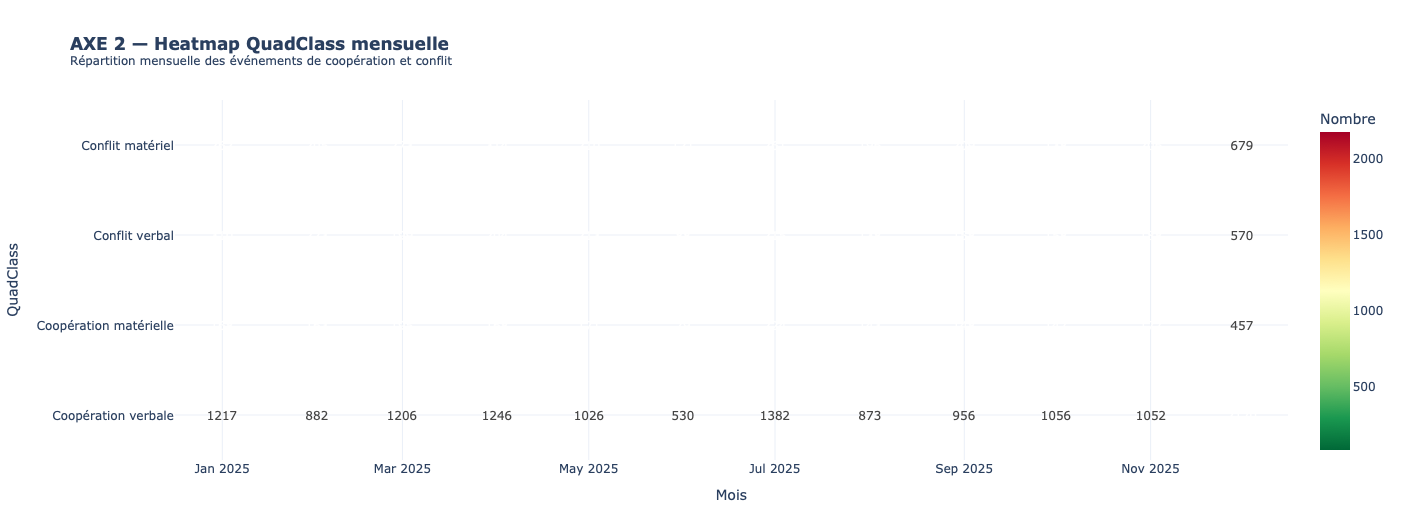

In [33]:
# ============================================================
# AXE 2 — Heatmap QuadClass mensuelle
# ============================================================

quad_labels = {
    1: "Coopération verbale",
    2: "Coopération matérielle",
    3: "Conflit verbal",
    4: "Conflit matériel"
}

df["QuadClass_label"] = df["QuadClass"].map(quad_labels).fillna("Autre")

quad_month = (
    df.groupby(["QuadClass_label", "month"])
    .size()
    .reset_index(name="count")
)

pivot_quad = quad_month.pivot(
    index="QuadClass_label",
    columns="month",
    values="count"
).fillna(0)

fig = px.imshow(
    pivot_quad,
    text_auto=True,
    color_continuous_scale="RdYlGn_r",
    title="<b>AXE 2 — Heatmap QuadClass mensuelle</b><br><sup>Répartition mensuelle des événements de coopération et conflit</sup>",
    labels=dict(x="Mois", y="QuadClass", color="Nombre")
)

fig.update_layout(
    width=1150,
    height=520,
    margin=dict(l=80, r=40, t=100, b=60)
)

fig.show()

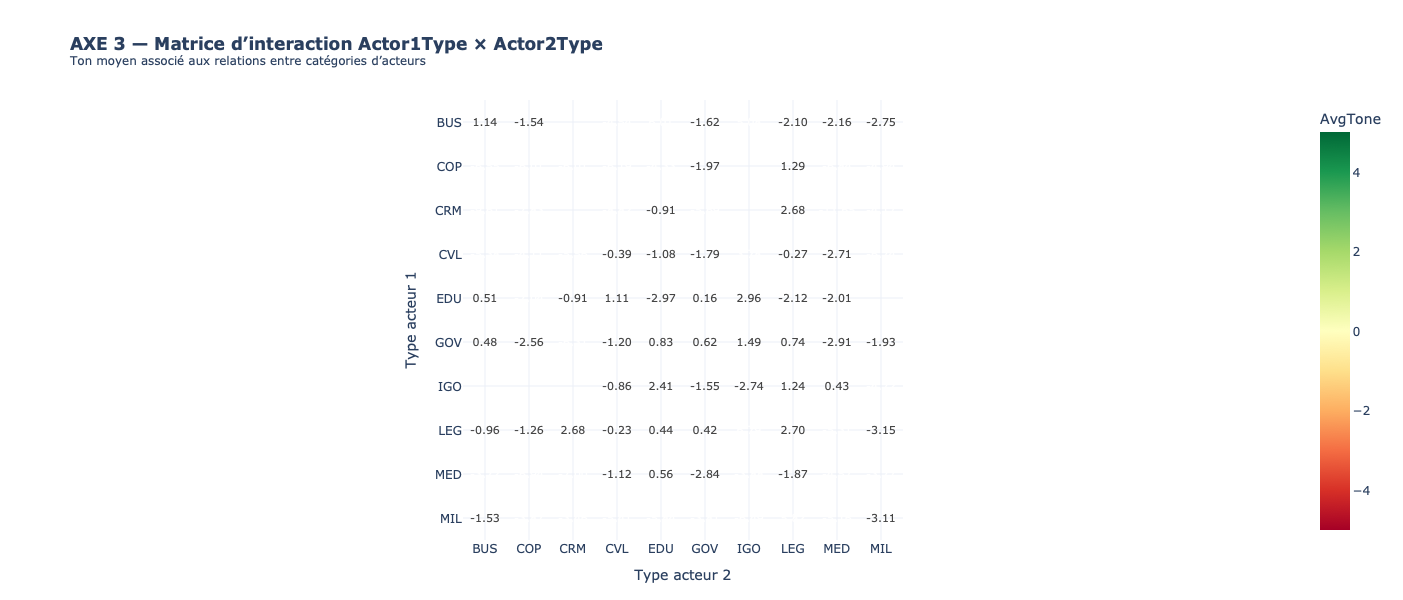

Insight Axe 3 :
La matrice permet d’identifier les combinaisons d’acteurs associées aux tons les plus négatifs, donc potentiellement aux rapports de force les plus sensibles.


In [35]:
# ============================================================
# AXE 3 — Matrice interaction Actor1Type × Actor2Type
# ============================================================

interaction_df = df.dropna(subset=["Actor1Type1Code", "Actor2Type1Code", "AvgTone"]).copy()

# Limiter aux types les plus fréquents pour lisibilité
top_actor_types = pd.concat([
    interaction_df["Actor1Type1Code"],
    interaction_df["Actor2Type1Code"]
]).value_counts().head(10).index.tolist()

interaction_df = interaction_df[
    interaction_df["Actor1Type1Code"].isin(top_actor_types) &
    interaction_df["Actor2Type1Code"].isin(top_actor_types)
]

interaction_matrix = (
    interaction_df
    .groupby(["Actor1Type1Code", "Actor2Type1Code"])
    .agg(
        avg_tone=("AvgTone", "mean"),
        count=("AvgTone", "size")
    )
    .reset_index()
)

pivot_tone = interaction_matrix.pivot(
    index="Actor1Type1Code",
    columns="Actor2Type1Code",
    values="avg_tone"
)

fig = px.imshow(
    pivot_tone,
    text_auto=".2f",
    color_continuous_scale="RdYlGn",
    zmin=-5,
    zmax=5,
    title="<b>AXE 3 — Matrice d’interaction Actor1Type × Actor2Type</b><br><sup>Ton moyen associé aux relations entre catégories d’acteurs</sup>",
    labels=dict(
        x="Type acteur 2",
        y="Type acteur 1",
        color="AvgTone"
    )
)

fig.update_layout(
    width=1050,
    height=600,
    margin=dict(l=80, r=40, t=100, b=60)
)

fig.show()

print("Insight Axe 3 :")
print(
    "La matrice permet d’identifier les combinaisons d’acteurs associées aux tons les plus négatifs, "
    "donc potentiellement aux rapports de force les plus sensibles."
)

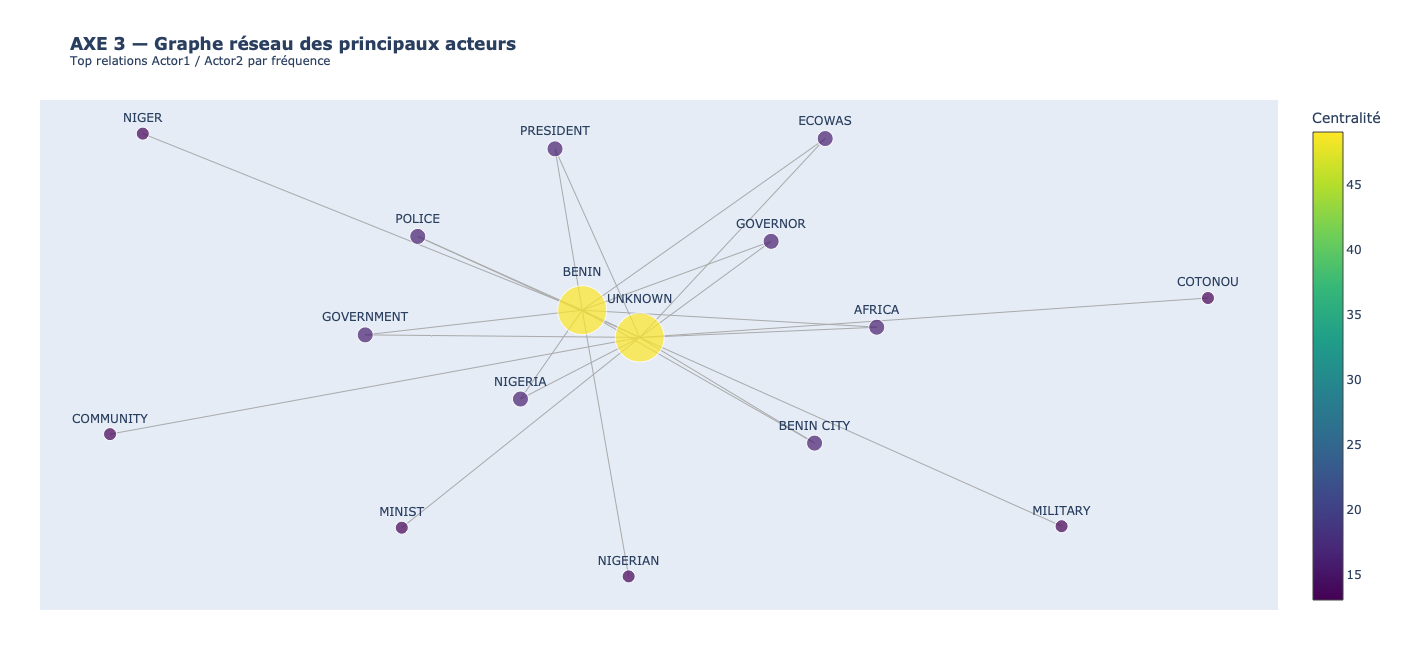

In [37]:
# ============================================================
# AXE 3 — Graphe réseau acteurs simplifié avec Plotly
# Alternative notebook-friendly à Pyvis
# ============================================================

import networkx as nx

network_df = df.dropna(subset=["Actor1Name", "Actor2Name"]).copy()

edges = (
    network_df.groupby(["Actor1Name", "Actor2Name"])
    .agg(
        weight=("date", "size"),
        avg_tone=("AvgTone", "mean")
    )
    .reset_index()
    .sort_values("weight", ascending=False)
    .head(30)
)

G = nx.Graph()

for _, row in edges.iterrows():
    G.add_edge(
        row["Actor1Name"],
        row["Actor2Name"],
        weight=row["weight"],
        avg_tone=row["avg_tone"]
    )

pos = nx.spring_layout(G, seed=42, k=0.8)

edge_x = []
edge_y = []

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=1, color="#AAAAAA"),
    hoverinfo="none",
    mode="lines",
    name="Relations"
)

node_x = []
node_y = []
node_text = []
node_size = []

degree_dict = dict(G.degree())

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    node_size.append(10 + degree_dict[node] * 3)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=node_text,
    textposition="top center",
    marker=dict(
        size=node_size,
        color=node_size,
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="Centralité")
    ),
    hoverinfo="text",
    name="Acteurs"
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title="<b>AXE 3 — Graphe réseau des principaux acteurs</b><br><sup>Top relations Actor1 / Actor2 par fréquence</sup>",
    showlegend=False,
    width=1100,
    height=650,
    margin=dict(l=40, r=40, t=100, b=40),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()

In [39]:
# ============================================================
# AXE 4 — Classification source locale / internationale
# ============================================================

from urllib.parse import urlparse

local_domains_keywords = [
    ".bj",
    "ortb",
    "lanation",
    "beninwebtv",
    "24haubenin",
    "matinlibre",
    "fraternitebj",
    "beninintelligent",
    "gouv.bj",
    "presidence.bj"
]

def extract_domain(url):
    try:
        return urlparse(str(url)).netloc.replace("www.", "")
    except:
        return np.nan

def classify_source(url):
    url_str = str(url).lower()
    for kw in local_domains_keywords:
        if kw in url_str:
            return "Nationale"
    return "Internationale"

df["source_domain"] = df["SOURCEURL"].apply(extract_domain)
df["source_type"] = df["SOURCEURL"].apply(classify_source)

df["source_type"].value_counts()

source_type
Internationale    21290
Nationale           284
Name: count, dtype: int64

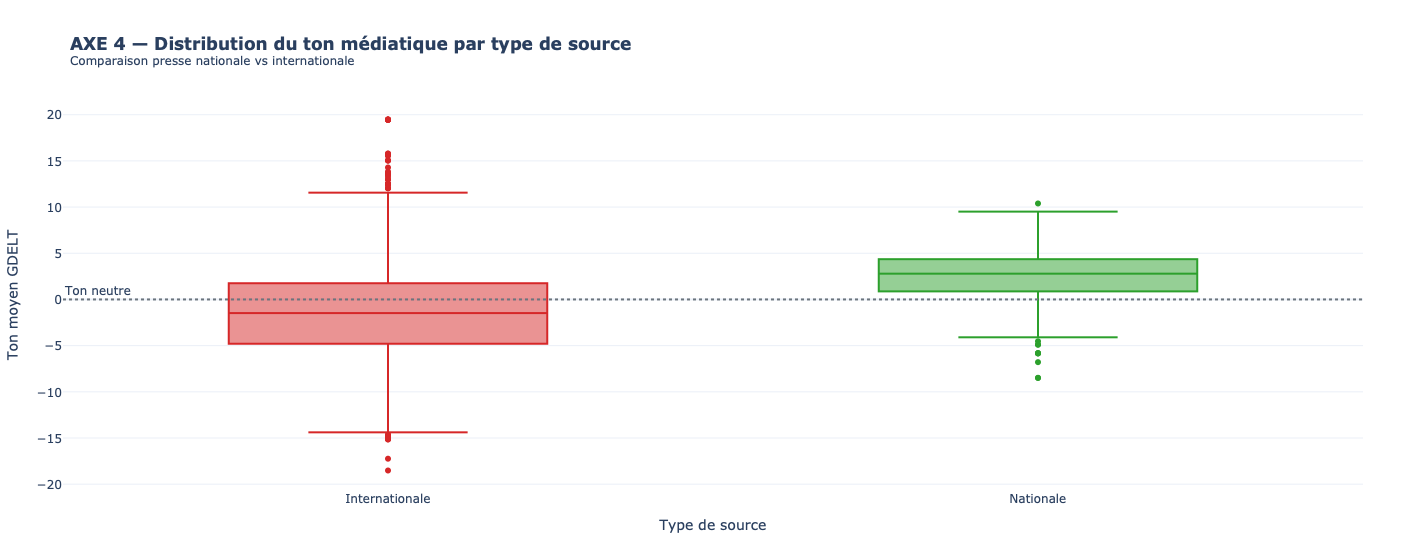

,source_type,avg_tone,median_tone,nb_articles,nb_events
0,Internationale,-1.554907,-1.477652,118203,21290
1,Nationale,2.453890,2.790698,3790,284


In [41]:
# ============================================================
# AXE 4 — Boxplot AvgTone par type de source
# ============================================================

fig = px.box(
    df.dropna(subset=["AvgTone", "source_type"]),
    x="source_type",
    y="AvgTone",
    color="source_type",
    points="outliers",
    title="<b>AXE 4 — Distribution du ton médiatique par type de source</b><br><sup>Comparaison presse nationale vs internationale</sup>",
    labels={
        "source_type": "Type de source",
        "AvgTone": "Ton moyen GDELT"
    },
    color_discrete_map={
        "Nationale": COLORS["green"],
        "Internationale": COLORS["red"]
    }
)

fig.add_hline(
    y=0,
    line_dash="dot",
    line_color=COLORS["gray"],
    annotation_text="Ton neutre",
    annotation_position="top left"
)

fig.update_layout(
    width=900,
    height=550,
    margin=dict(l=60, r=40, t=100, b=60),
    showlegend=False
)

fig.show()

source_summary = (
    df.groupby("source_type")
    .agg(
        avg_tone=("AvgTone", "mean"),
        median_tone=("AvgTone", "median"),
        nb_articles=("NumArticles", "sum"),
        nb_events=("date", "size")
    )
    .reset_index()
)

display(source_summary)

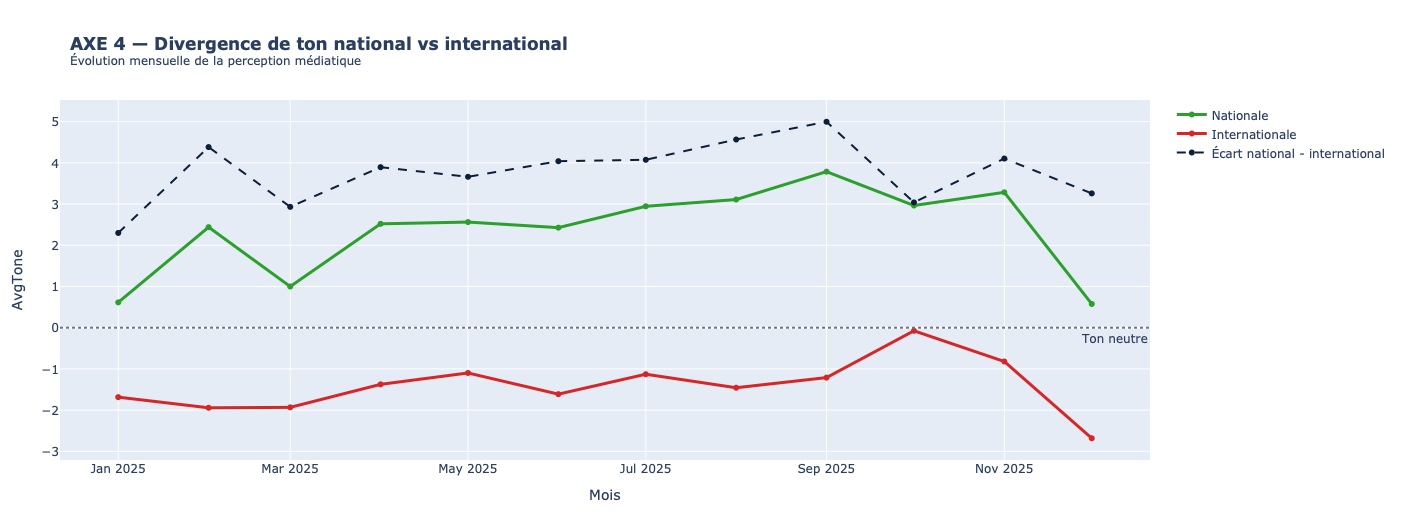

In [43]:
# ============================================================
# AXE 4 — Courbe divergence nationale vs internationale
# ============================================================

monthly_source = (
    df.groupby(["month", "source_type"])
    .agg(avg_tone=("AvgTone", "mean"))
    .reset_index()
)

pivot_source = monthly_source.pivot(
    index="month",
    columns="source_type",
    values="avg_tone"
).reset_index()

if "Nationale" in pivot_source.columns and "Internationale" in pivot_source.columns:
    pivot_source["ecart"] = pivot_source["Nationale"] - pivot_source["Internationale"]
else:
    pivot_source["ecart"] = np.nan

fig = go.Figure()

if "Nationale" in pivot_source.columns:
    fig.add_trace(go.Scatter(
        x=pivot_source["month"],
        y=pivot_source["Nationale"],
        mode="lines+markers",
        name="Nationale",
        line=dict(color=COLORS["green"], width=3)
    ))

if "Internationale" in pivot_source.columns:
    fig.add_trace(go.Scatter(
        x=pivot_source["month"],
        y=pivot_source["Internationale"],
        mode="lines+markers",
        name="Internationale",
        line=dict(color=COLORS["red"], width=3)
    ))

fig.add_trace(go.Scatter(
    x=pivot_source["month"],
    y=pivot_source["ecart"],
    mode="lines+markers",
    name="Écart national - international",
    line=dict(color=COLORS["dark"], width=2, dash="dash")
))

fig.add_hline(
    y=0,
    line_dash="dot",
    line_color=COLORS["gray"],
    annotation_text="Ton neutre",
    annotation_position="bottom right"
)

fig.update_layout(
    title="<b>AXE 4 — Divergence de ton national vs international</b><br><sup>Évolution mensuelle de la perception médiatique</sup>",
    xaxis_title="Mois",
    yaxis_title="AvgTone",
    hovermode="x unified",
    width=1100,
    height=520,
    margin=dict(l=60, r=40, t=100, b=60)
)

fig.show()

In [45]:
# ============================================================
# AXE 5 — Zones géographiques et indice de tension
# ============================================================

geo_df = df.dropna(subset=["ActionGeo_Lat", "ActionGeo_Long"]).copy()

# Bornes simples adaptées au Bénin :
# Sud : littoral / Cotonou / Porto-Novo
# Centre : zone médiane
# Nord : zones frontalières et septentrionales

def benin_zone(lat):
    if lat >= 10:
        return "Nord"
    elif lat >= 7.5:
        return "Centre"
    else:
        return "Sud"

geo_df["zone"] = geo_df["ActionGeo_Lat"].apply(benin_zone)

# Indice de tension :
# plus Goldstein est négatif et plus AvgTone est négatif, plus la tension augmente.
geo_df["tension_raw"] = (
    (-geo_df["GoldsteinScale"].fillna(0)) +
    (-geo_df["AvgTone"].fillna(0))
)

# Normalisation 0–100
t_min = geo_df["tension_raw"].min()
t_max = geo_df["tension_raw"].max()

geo_df["tension_index"] = 100 * (geo_df["tension_raw"] - t_min) / (t_max - t_min)

zone_summary = (
    geo_df.groupby("zone")
    .agg(
        tension_index=("tension_index", "mean"),
        nb_events=("date", "size"),
        avg_tone=("AvgTone", "mean"),
        avg_goldstein=("GoldsteinScale", "mean"),
        lat=("ActionGeo_Lat", "mean"),
        lon=("ActionGeo_Long", "mean")
    )
    .reset_index()
)

zone_summary

,zone,tension_index,nb_events,avg_tone,avg_goldstein,lat,lon
0,Centre,49.160711,20076,-1.476952,0.525907,9.490920,2.252754
1,Nord,63.118924,599,-5.401447,-2.145743,11.175624,2.409014
2,Sud,42.606447,899,0.533581,1.612681,6.690777,2.215699


In [51]:
# ============================================================
# AXE 5 — Carte zonée Nord / Centre / Sud
# ============================================================

center_lat = 9.3
center_lon = 2.3

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles="CartoDB positron"
)

def tension_color(score):
    if score < 25:
        return "green"
    elif score < 50:
        return "orange"
    elif score < 75:
        return "red"
    else:
        return "darkred"

for _, row in zone_summary.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=18 + row["nb_events"] / zone_summary["nb_events"].max() * 30,
        color=tension_color(row["tension_index"]),
        fill=True,
        fill_opacity=0.65,
        popup=folium.Popup(
            f"""
            <b>Zone : {row['zone']}</b><br>
            Indice tension : {row['tension_index']:.1f}/100<br>
            Nombre événements : {row['nb_events']}<br>
            AvgTone : {row['avg_tone']:.2f}<br>
            Goldstein moyen : {row['avg_goldstein']:.2f}
            """,
            max_width=300
        ),
        tooltip=f"{row['zone']} — Tension {row['tension_index']:.1f}/100"
    ).add_to(m)

legend_html = """
<div style="
position: fixed; 
bottom: 40px; left: 40px; width: 230px; height: 150px; 
background-color: white; z-index:9999; font-size:14px;
border:2px solid grey; border-radius:8px; padding: 10px;
">
<b>Indice de tension</b><br>
<span style="color:green;">●</span> 0–25 : Faible<br>
<span style="color:orange;">●</span> 25–50 : Modéré<br>
<span style="color:red;">●</span> 50–75 : Élevé<br>
<span style="color:darkred;">●</span> 75–100 : Très élevé<br>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

display(m)

In [49]:
# ============================================================
# AXE 5 — Heatmap géographique mensuelle
# Version notebook Folium
# ============================================================

m_heat = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles="CartoDB positron"
)

# On pondère la heatmap par l'indice de tension
heat_data = geo_df[
    ["ActionGeo_Lat", "ActionGeo_Long", "tension_index"]
].dropna().values.tolist()

HeatMap(
    heat_data,
    radius=18,
    blur=20,
    max_zoom=10
).add_to(m_heat)

display(m_heat)